# 01 - Mechanistic Model

Baseline Jinan 2023 case: weather acquisition, load generation, PV and wind generation. Calls functions from `src.data.*`, `src.physics.*`, and `src.visualization.*` only -- no modelling logic is written here (PROJECT_BRIEF.md §25, §1.6).

Battery dispatch and the battery-size optimization sweep (Stage 3) are covered once `src.physics.optimization` is implemented; this notebook currently covers the Stage 2 components only.

In [1]:
%matplotlib inline
import sys
import logging
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO)

from src.config import load_site_config
from src.data.weather import get_processed_weather
from src.physics.load_profile import generate_load_profile
from src.physics.pv_model import compute_pv_generation
from src.physics.wind_model import compute_wind_generation, adjust_wind_speed_to_hub_height
from src.visualization.plotting import (
    plot_annual_profile, plot_representative_week, plot_load_duration_curve,
    plot_monthly_energy, plot_wind_speed_distribution_and_power_curve, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
config = load_site_config("jinan")
config

{'site': {'name': 'jinan',
  'latitude': 36.65,
  'longitude': 117.12,
  'timezone': 'Asia/Shanghai',
  'elevation_m': 51},
 'simulation': {'year': 2023, 'expected_hourly_records': 8760},
 'load': {'target_annual_kwh': 30000,
  'max_hourly_kw': 15,
  'profile_family': 'residential_baseline',
  'random_seed': 42},
 'pv': {'capacity_kwp': 20.0,
  'tilt_deg': 36.65,
  'azimuth_deg': 180.0,
  'system_losses_fraction': 0.14,
  'inverter_efficiency': 0.96},
 'wind': {'rated_power_kw': 10.0,
  'hub_height_m': 15.0,
  'wind_shear_exponent': 0.14,
  'cut_in_mps': 2.5,
  'rated_mps': 11.0,
  'cut_out_mps': 25.0,
  'weather_reference_height_m': 10},
 'battery': {'chemistry': 'LFP',
  'module_capacity_kwh': 15.36,
  'module_rated_power_kw': 12.8,
  'round_trip_efficiency': 0.95,
  'min_soc_fraction': 0.1,
  'max_soc_fraction': 0.95,
  'initial_soc_fraction': 0.5,
  'economic_lifetime_years': 10,
  'project_lifetime_years': 20,
  'installed_cost_eur_per_kwh': 550,
  'cost_sensitivity_eur_per_kwh': 

## Weather data

See `data/README.md` for the NASA POWER API validation findings (time standard, units, wind reference height) this pipeline relies on.

In [2]:
weather = get_processed_weather("jinan", config["simulation"]["year"])
weather.to_csv(TABLES_DIR / "baseline_hourly_weather.csv", index_label="timestamp")
weather.describe()

INFO:src.data.weather:Loading cached processed weather from /home/user/Leonardo-Assignment/data/processed/jinan_2023_weather.csv


,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,T2M,WS10M
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,175.671842,162.004216,73.605250,13.659402,3.790208
std,252.473951,262.093952,99.690847,12.030952,2.023951
min,0.000000,0.000000,0.000000,-20.600000,0.080000
25%,0.000000,0.000000,0.000000,3.190000,2.290000
50%,6.930000,0.000000,8.360000,15.065000,3.400000
75%,310.505000,262.485000,132.192500,23.540000,4.940000
max,985.880000,1057.940000,533.090000,40.090000,13.850000


## Load profile

In [3]:
load = generate_load_profile(
    annual_consumption_kwh=config["load"]["target_annual_kwh"],
    peak_load_kw=config["load"]["max_hourly_kw"],
    year=config["simulation"]["year"],
    timezone=config["site"]["timezone"],
    random_seed=config["load"]["random_seed"],
    profile_family=config["load"]["profile_family"],
)
load.to_csv(TABLES_DIR / "baseline_hourly_load.csv", index_label="timestamp", header=["load_kw"])
print(f"Annual: {load.sum():.0f} kWh, peak: {load.max():.2f} kW, mean: {load.mean():.2f} kW")
load.describe()

INFO:src.physics.load_profile:Generated load profile: annual=30000.0 kWh, peak=8.00 kW, mean=3.425 kW, n=8760


Annual: 30000 kWh, peak: 8.00 kW, mean: 3.42 kW


count    8760.000000
mean        3.424658
std         1.375934
min         1.043992
25%         2.334559
50%         3.342634
75%         4.385053
max         7.996207
Name: load_kw, dtype: float64

## PV generation

In [4]:
pv = compute_pv_generation(
    weather=weather,
    capacity_kwp=config["pv"]["capacity_kwp"],
    latitude=config["site"]["latitude"],
    longitude=config["site"]["longitude"],
    tilt_deg=config["pv"]["tilt_deg"],
    azimuth_deg=config["pv"]["azimuth_deg"],
    system_losses_fraction=config["pv"]["system_losses_fraction"],
    inverter_efficiency=config["pv"]["inverter_efficiency"],
)
print(f"Annual: {pv.sum():.0f} kWh, capacity factor: {pv.sum() / (config['pv']['capacity_kwp'] * len(pv)):.3f}")
pv.describe()

INFO:src.physics.pv_model:Computed PV generation: capacity=20.0 kWp, annual=25693.7 kWh, capacity_factor=0.147


Annual: 25694 kWh, capacity factor: 0.147


count    8760.000000
mean        2.933067
std         4.241213
min         0.000000
25%         0.000000
50%         0.136690
75%         5.182695
max        17.568647
Name: pv_kw, dtype: float64

## Wind generation

In [5]:
wind = compute_wind_generation(
    weather=weather,
    rated_power_kw=config["wind"]["rated_power_kw"],
    reference_height_m=config["wind"]["weather_reference_height_m"],
    hub_height_m=config["wind"]["hub_height_m"],
    shear_exponent=config["wind"]["wind_shear_exponent"],
    cut_in_mps=config["wind"]["cut_in_mps"],
    rated_mps=config["wind"]["rated_mps"],
    cut_out_mps=config["wind"]["cut_out_mps"],
)
print(f"Annual: {wind.sum():.0f} kWh, capacity factor: {wind.sum() / (config['wind']['rated_power_kw'] * len(wind)):.3f}")

pv.to_frame("pv_kw").join(wind.to_frame("wind_kw")).to_csv(
    TABLES_DIR / "baseline_pv_wind_generation.csv", index_label="timestamp"
)
wind.describe()

INFO:src.physics.wind_model:Computed wind generation: rated=10.0 kW, annual=7523.4 kWh, capacity_factor=0.086


Annual: 7523 kWh, capacity factor: 0.086


count    8760.000000
mean        0.858838
std         1.541099
min         0.000000
25%         0.000000
50%         0.235492
75%         0.967862
max        10.000000
Name: wind_kw, dtype: float64

## Required figures (PROJECT_BRIEF.md §27, mechanistic figures 1-6)

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/01_annual_profile.png


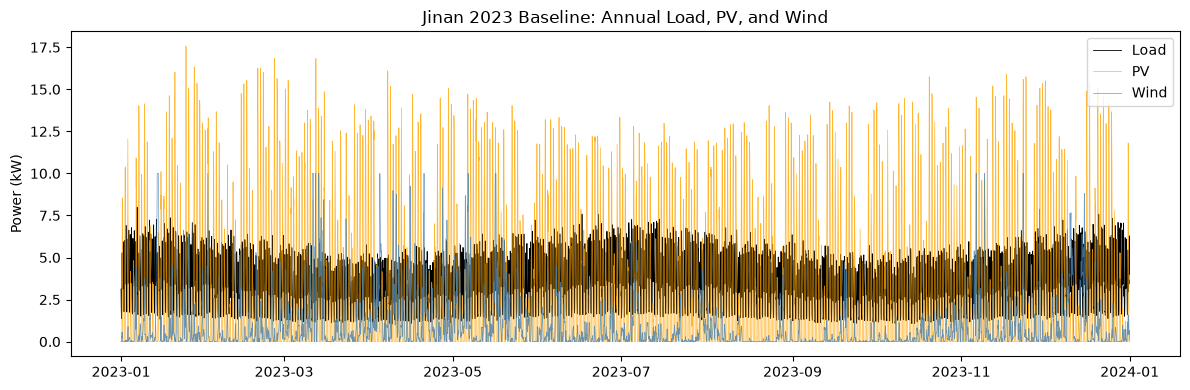

In [6]:
fig = plot_annual_profile(load, pv, wind, "Jinan 2023 Baseline: Annual Load, PV, and Wind")
save_figure(fig, FIGURES_DIR / "01_annual_profile.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/02_winter_week.png


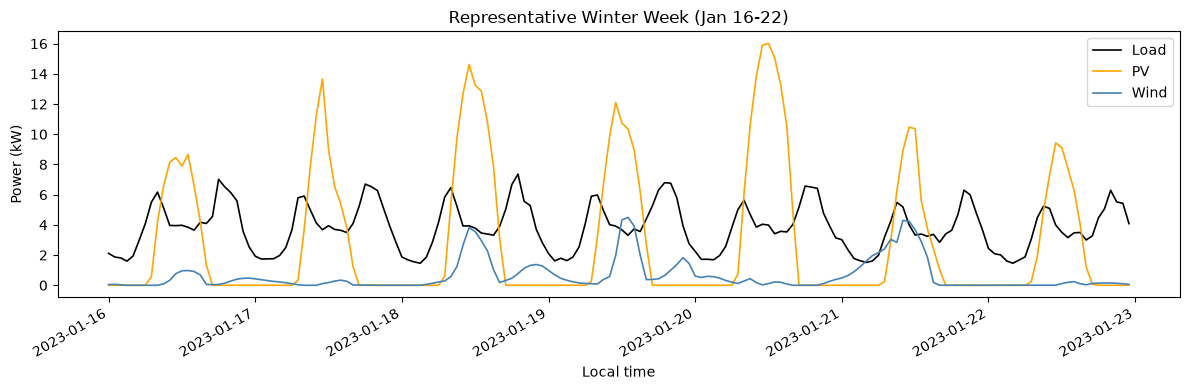

In [7]:
fig = plot_representative_week(load, pv, wind, "2023-01-16", "Representative Winter Week (Jan 16-22)")
save_figure(fig, FIGURES_DIR / "02_winter_week.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/03_summer_week.png


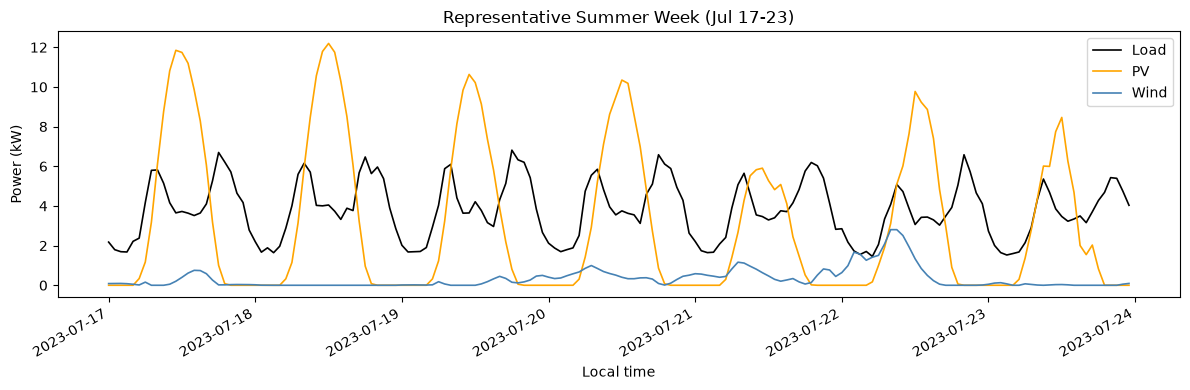

In [8]:
fig = plot_representative_week(load, pv, wind, "2023-07-17", "Representative Summer Week (Jul 17-23)")
save_figure(fig, FIGURES_DIR / "03_summer_week.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/04_load_duration_curve.png


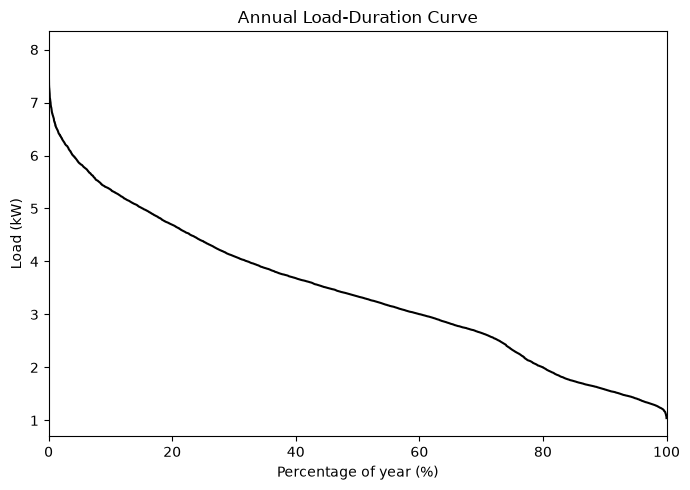

In [9]:
fig = plot_load_duration_curve(load)
save_figure(fig, FIGURES_DIR / "04_load_duration_curve.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/05_monthly_energy.png


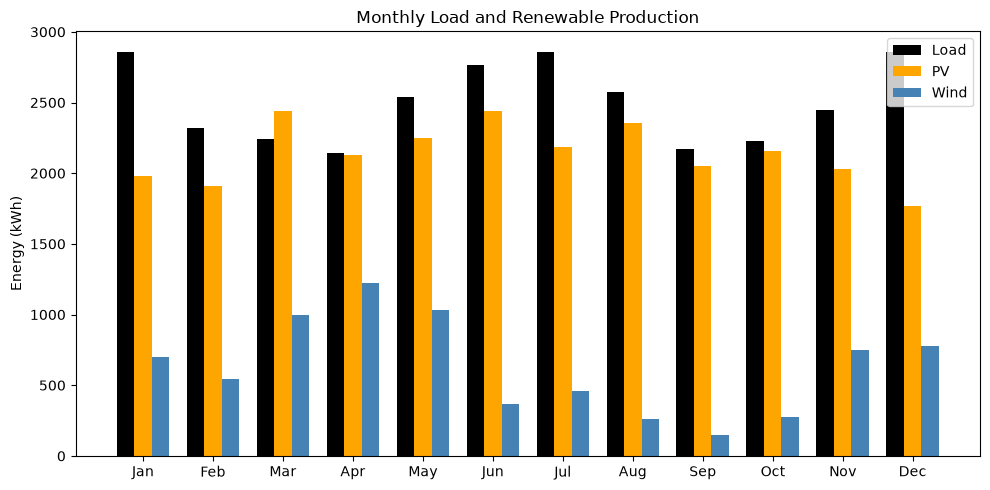

In [10]:
fig = plot_monthly_energy(load, pv, wind)
save_figure(fig, FIGURES_DIR / "05_monthly_energy.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/06_wind_speed_power_curve.png


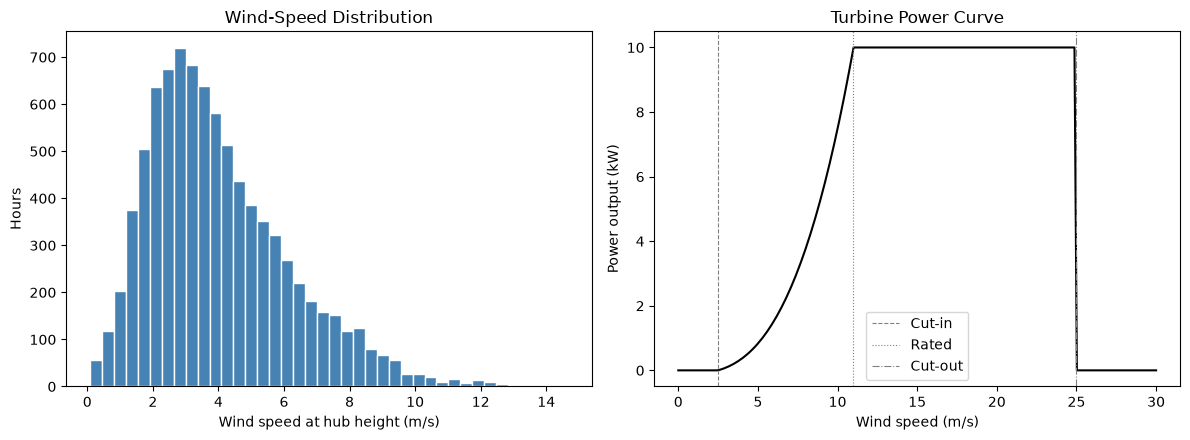

In [11]:
wind_speed_hub = adjust_wind_speed_to_hub_height(
    weather["WS10M"], config["wind"]["weather_reference_height_m"],
    config["wind"]["hub_height_m"], config["wind"]["wind_shear_exponent"],
)
fig = plot_wind_speed_distribution_and_power_curve(
    wind_speed_hub, config["wind"]["rated_power_kw"], config["wind"]["cut_in_mps"],
    config["wind"]["rated_mps"], config["wind"]["cut_out_mps"],
)
save_figure(fig, FIGURES_DIR / "06_wind_speed_power_curve.png")

## Next steps

Battery dispatch (`src.physics.dispatch`) and the exhaustive battery-size search (`src.physics.optimization`, Stage 3) will extend this notebook with: LPSP/curtailment/cost vs. battery capacity, representative SOC profiles, and the annual energy-flow balance (figures 7-11).